## Second Experiment Figures

Objective: Explain the differences in radar responses with variations in amounts of petroleum jelly and water.


### Loading Dataset

In [1]:
from premade_fns import range_angle_matrix_for_N_samples
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "grid.color": "dimgray",    # or "0.2" for near-black
    "grid.alpha": 0.6           # make them semi-transparent
})

# --------- SET BIGGER FONTS (good for slides) ----------
plt.rcParams.update({
    "figure.figsize": (12, 6),        # a bit bigger figure
    "axes.titlesize": 24,             # title font
    "axes.labelsize": 20,             # x/y axis label
    "xtick.labelsize": 18,            # tick labels
    "ytick.labelsize": 18,
    "legend.fontsize": 18,            # legend
    "lines.linewidth": 3,             # thicker lines
})

In [2]:
min_bin = 7
max_bin = 13

In [3]:
from pathlib import Path
import numpy as np

BASE_DIR = Path("../datasets/Second Experiment")

data = {}

for subdir in BASE_DIR.iterdir():
    if subdir.is_dir():
        npy_files = sorted(subdir.glob("*.npy"), key=lambda p: int(p.stem))

        out = []
        for f in npy_files:
            raw = np.load(f)
            proc = range_angle_matrix_for_N_samples(raw, norm=True)[:, min_bin:max_bin] / 100

            sv = np.sort(proc, axis=0)
            trimmed = sv[15:-15]
            out.append(trimmed.mean(axis=0))

        data[subdir.name] = np.stack(out, axis=0)


### Plotting

3x3 heatmaps (Pretty bad)

In [4]:
# import matplotlib.pyplot as plt

# for key in sorted(data.keys()):
#     arr = data[key]   # (9, 5, 11)

#     fig, axes = plt.subplots(3, 3, figsize=(10, 8), constrained_layout=True)
#     fig.suptitle(key)

#     for i in range(9):
#         ax = axes.flat[i]
#         im = ax.imshow(arr[i],
#                        aspect="auto",
#                        vmin=-1.3,
#                        vmax=-0.7)
#         ax.set_title(f"{key} #{i+1}")
#         ax.set_xticks([])
#         ax.set_yticks([])

#     fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
#     plt.show()


Middle view only (also not good)

In [5]:
# import matplotlib.pyplot as plt
# import numpy as np

# baseline = data["w0.0"][4]    # (5,11)

# for key in sorted(data.keys()):
#     arr = data[key]
#     mid = arr[4]              # the 5th matrix

#     corrected = mid - baseline

#     plt.figure(figsize=(4, 4), constrained_layout=True)
#     plt.title(f"{key}")
#     im = plt.imshow(corrected, aspect="auto", vmin=-0.2, vmax=0.15)
#     plt.xticks([])
#     plt.yticks([])
#     plt.colorbar(im)
#     plt.show()


Line plots of each range bin (promising)



In [6]:
# import numpy as np
# import matplotlib.pyplot as plt

# x = np.arange(11)

# groups = {
#     # Uncomment as needed
#     "JB": [k for k in sorted(data.keys()) if k.startswith("jb") or k.startswith("JB")],
#     # "J":  [k for k in sorted(data.keys()) if k.startswith("j")  and not (k.startswith("jb") or k.startswith("JB"))],
#     # "W":  [k for k in sorted(data.keys()) if k.startswith("w") or k.startswith("W")],
# }

# for group_name, keys in groups.items():
#     for i in range(max_bin-min_bin):
#         plt.figure(figsize=(8, 5))
#         for key in keys:
#             row = data[key][7, i, :]
#             plt.plot(x, row, label=key)

#         plt.xlabel("Bin index")
#         plt.ylabel("Value")
#         plt.title(f"Row {i} (5th matrix) — {group_name} group")
#         plt.legend(fontsize=8)
#         plt.tight_layout()
#         plt.show()


In [7]:
# import numpy as np
# import matplotlib.pyplot as plt

# x = np.arange(max_bin-min_bin)

# groups = {
#     "JB": [k for k in sorted(data.keys()) if k.lower().startswith("jb")],
#     "J":  [k for k in sorted(data.keys()) if k.lower().startswith("j") and not k.lower().startswith("jb")],
#     "W":  [k for k in sorted(data.keys()) if k.lower().startswith("w")],
# }

# for group_name, keys in groups.items():
#     plt.figure(figsize=(8, 5))

#     for key in keys:
#         col_mean = data[key][4].min(axis=1)  # (5,)
#         plt.plot(x, col_mean, label=key)

#     plt.xlabel("Row index (0–4)")
#     plt.ylabel("Mean over angle bins")
#     plt.title(f"Mean over angle bins — {group_name} group")
#     plt.legend(fontsize=8)
#     plt.tight_layout()
#     plt.show()


### Brute Force Feature Extraction

total — Sum of all values in the range–angle map, representing overall reflected energy.

energy_range — Energy summed across each range bin (5-length vector showing depth distribution).

energy_angle — Energy summed across each angle bin (11-length vector showing angular distribution).

range_com — Center of mass along the range axis indicating where energy is concentrated in depth.

angle_com — Center of mass along the angle axis showing the lateral position of dominant energy.

angle_var — Variance of angular energy around the strongest beam, measuring angular spread.

range_var — Variance of range energy around the strongest range bin, measuring depth spread.

angle_entropy — Entropy of angular energy, capturing how diffuse or concentrated the angular pattern is.

angle_contrast — Ratio of energy in the central beam to outer beams, indicating beam sharpness or spread.

peak_range / peak_angle — Indices of the maximum-energy point in the map, giving peak location.

flat — Flattened 55-element vector preserving the entire map for ML models.


In [8]:
data["j0.0"] = data["w0.0"]

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

# ============================================================
# 1. Feature extraction from a single 5x11 range-angle matrix
# ============================================================

def extract_features(mat):
    feats = {}

    # ------------- Energy features -------------
    # Per-range and per-angle energy
    energy_range = mat.sum(axis=1)   # shape (5,)
    energy_angle = mat.sum(axis=0)   # shape (11,)

    feats["total"] = float(energy_range.sum())
    # feats["energy_range"] = energy_range.tolist()   # len 5 (kept for now)
    # feats["energy_angle"] = energy_angle.tolist()   # len 11 (kept for now)

    # Combined / aggregated energy features (range)
    #   - "near" = first 2 range bins
    #   - "far"  = last 2 range bins
    near_range = energy_range[0] + energy_range[1]
    far_range  = energy_range[-1] + energy_range[-2]

    feats["energy_range_near"] = float(near_range)
    feats["energy_range_far"]  = float(far_range)
    feats["energy_range_balance"] = float(
        (far_range - near_range) / (feats["total"] + 1e-9)
    )

    # Combined / aggregated energy features (angle)
    #   - "center" = 3 beams around the middle (4,5,6)
    #   - "edges"  = two beams on each side (0,1,9,10)
    center_angle = energy_angle[4:7].sum()
    edge_angle   = energy_angle[0] + energy_angle[1] + energy_angle[9] + energy_angle[10]

    feats["energy_angle_center"] = float(center_angle)
    feats["energy_angle_edges"]  = float(edge_angle)
    feats["energy_angle_balance"] = float(
        center_angle / (edge_angle + 1e-9)
    )

    # ------------- Center of mass -------------
    ri = np.arange(mat.shape[0])   # 0..4
    ai = np.arange(mat.shape[1])   # 0..10

    feats["range_com"] = float((energy_range @ ri) / (feats["total"] + 1e-9))
    feats["angle_com"] = float((energy_angle @ ai) / (feats["total"] + 1e-9))

    # ------------- Variance -------------
    p = energy_angle / (energy_angle.sum() + 1e-9)
    feats["angle_var"] = float(np.sum(p * (ai - p.argmax())**2))

    q = energy_range / (energy_range.sum() + 1e-9)
    feats["range_var"] = float(np.sum(q * (ri - q.argmax())**2))

    # ------------- Entropy -------------
    feats["angle_entropy"] = float(-np.sum(p * np.log(p + 1e-9)))

    # ------------- Contrast -------------
    # center beam vs outer beams (slightly different from energy_angle_balance)
    feats["angle_contrast"] = float(
        mat[:, 5].sum() / (mat[:, [0, 1, 9, 10]].sum() + 1e-9)
    )

    # ------------- Peak positions -------------
    max_idx = np.unravel_index(mat.argmax(), mat.shape)
    feats["peak_range"], feats["peak_angle"] = max_idx

    return feats



# ============================================================
# 2. Extract features for ALL samples in data (9 maps per file)
#    data[key] has shape (9, 5, 11)
# ============================================================

all_features = {}

for key, arr in data.items():
    all_features[key] = [extract_features(arr[i]) for i in range(arr.shape[0])]


# ============================================================
# 3. Extract numerical volume from key names
# ============================================================

def extract_volume(key):
    for i, ch in enumerate(key):
        if (ch.isdigit() or ch == "."):
            return float(key[i:])
    return None

volumes = {key: extract_volume(key) for key in all_features.keys()}


# ============================================================
# 4. Build a unified feature matrix X and volume vector y
# ============================================================

feature_names = []
X_list = []
y_list = []

for key, feat_list in all_features.items():
    # Average features across the 9 maps for this file
    merged = {}

    for fname in feat_list[0].keys():
        vals = np.array([f[fname] for f in feat_list])
        merged[fname] = vals.mean(axis=0)

    # Convert merged dict into single flat vector
    row = []
    local_names = []

    for fname, val in merged.items():
        val = np.ravel(val)
        row.extend(val)
        local_names.extend([f"{fname}_{i}" for i in range(len(val))])

    if not feature_names:
        feature_names = local_names

    X_list.append(row)
    y_list.append(volumes[key])

X = np.array(X_list)
y = np.array(y_list)


# ============================================================
# 5. Split into J / JB / W groups
# ============================================================

keys = list(all_features.keys())

def group_name(k):
    k = k.lower()
    if k.startswith("jb"):
        return "JB"
    elif k.startswith("j"):
        return "J"
    elif k.startswith("w"):
        return "W"
    return "OTHER"

groups = {"J": [], "JB": [], "W": []}

for idx, key in enumerate(keys):
    groups[group_name(key)].append(idx)

print("Samples per group:", {g: len(groups[g]) for g in groups})


# ============================================================
# 6. Analysis function for each substance group
# ============================================================

def analyze_group(G):
    print(f"\n=== Analyzing group: {G} ===")

    idxs = groups[G]
    Xg = X[idxs]
    yg = y[idxs]

    print("Samples:", len(yg))

    df = pd.DataFrame(Xg, columns=feature_names)
    df["volume"] = yg

    # ---- Correlation ----
    corr = df.corr()["volume"].sort_values(ascending=False)
    print("\nTop correlated features:")
    print(corr)

    # ---- Mutual Information ----
    mi = mutual_info_regression(Xg, yg)
    mi_series = pd.Series(mi, index=feature_names).sort_values(ascending=False)


    return corr, mi_series


# ============================================================
# 7. Run analysis for J, JB, and W
# ============================================================

results = {}
for G in ["J", "JB", "W"]:
    results[G] = analyze_group(G)


Samples per group: {'J': 7, 'JB': 7, 'W': 7}

=== Analyzing group: J ===
Samples: 7

Top correlated features:
volume                    1.000000
peak_range_0              0.534522
energy_range_balance_0    0.531232
range_com_0               0.515197
range_var_0               0.393982
angle_var_0               0.076675
angle_contrast_0         -0.065112
energy_angle_balance_0   -0.065231
angle_com_0              -0.127078
peak_angle_0             -0.205161
angle_entropy_0          -0.255362
energy_range_far_0       -0.591679
energy_angle_center_0    -0.725287
total_0                  -0.789087
energy_range_near_0      -0.804797
energy_angle_edges_0     -0.812374
Name: volume, dtype: float64

=== Analyzing group: JB ===
Samples: 7

Top correlated features:
volume                    1.000000
range_var_0               0.608415
peak_range_0              0.523139
angle_var_0               0.328100
energy_range_balance_0    0.298327
range_com_0               0.259901
peak_angle_0             

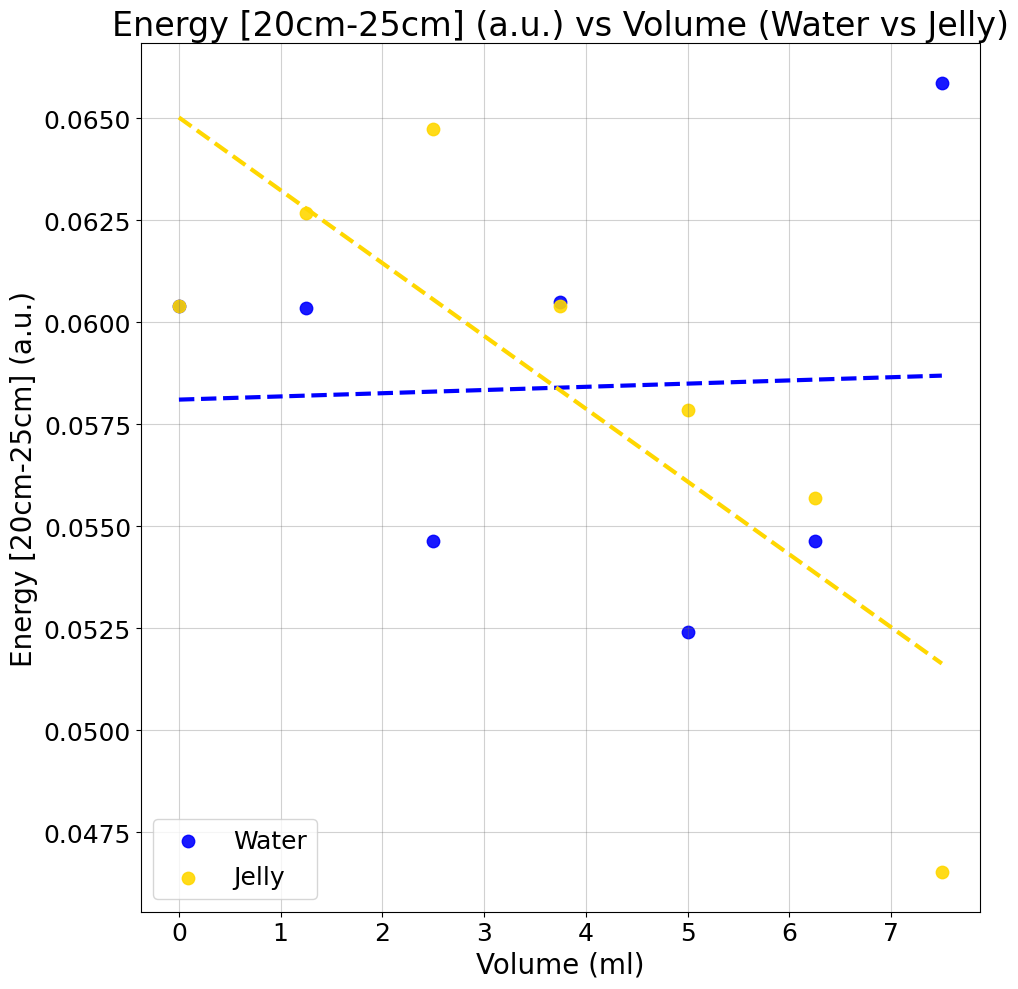

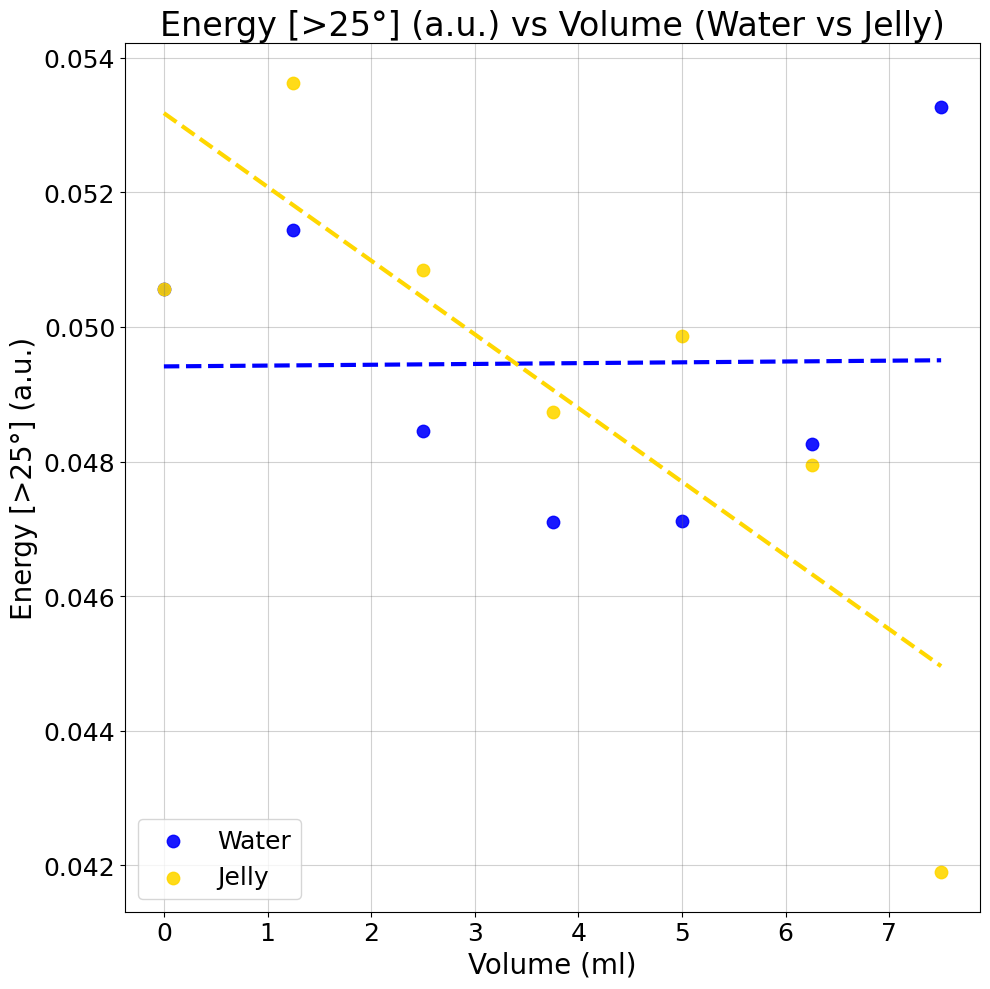

In [17]:
import numpy as np
import matplotlib.pyplot as plt

features = {
    "energy_range_near_0":  "Energy [20cm-25cm] (a.u.)",
    "energy_angle_edges_0": "Energy [>25°] (a.u.)",
}

colors = {
    "W": "blue",
    "J": "gold"
}

df_all = pd.DataFrame(X, columns=feature_names)
df_all["volume"] = y
df_all["group"] = [group_name(k) for k in keys]

for feat, title in features.items():
    plt.figure(figsize=(10, 10))

    for G in ["W", "J"]:   # only Water & Jelly
        sub = df_all[df_all["group"] == G]

        x = sub["volume"].values
        y = sub[feat].values

        # Scatter
        plt.scatter(x, y,
                    color=colors[G],
                    s=80,
                    alpha=0.9,
                    label="Water" if G == "W" else "Jelly")

        # Regression line
        if len(x) > 1:
            m, b = np.polyfit(x, y, 1)
            xfit = np.linspace(x.min(), x.max(), 100)
            plt.plot(xfit, m * xfit + b,
                     color=colors[G],
                     linestyle="--")

    plt.xlabel("Volume (ml)")
    plt.ylabel(title)
    plt.title(f"{title} vs Volume (Water vs Jelly)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


### Manipulating the raw data files

jb0.0: mean=0.2891
jb1.25: mean=0.3054
jb2.5: mean=0.2623
jb3.75: mean=0.2487
jb5.0: mean=0.2462
jb6.25: mean=0.2534
jb7.5: mean=0.1869


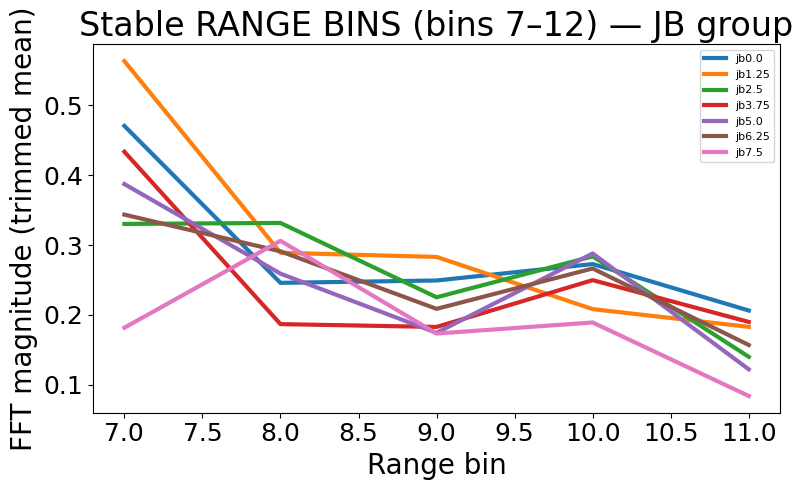

j1.25: mean=0.2139
j2.5: mean=0.2300
j3.75: mean=0.2670
j5.0: mean=0.2851
j6.25: mean=0.2319
j7.5: mean=0.2198


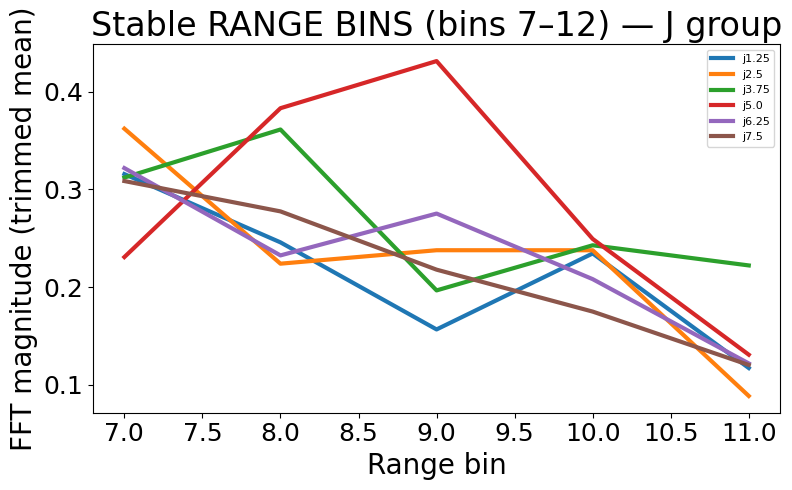

w0.0: mean=0.2501
w1.25: mean=0.2156
w2.5: mean=0.2434
w3.75: mean=0.2183
w5.0: mean=0.3077
w6.25: mean=0.2105
w7.5: mean=0.2882


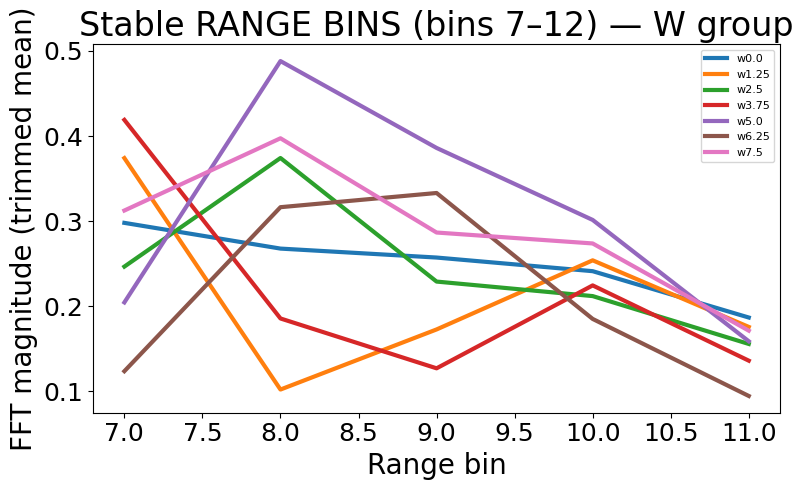

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path("../datasets/Second Experiment")

borehole = {}

for subdir in BASE_DIR.iterdir():
    if subdir.is_dir():
        npy_files = sorted(subdir.glob("*.npy"), key=lambda p: int(p.stem))

        bh_path = npy_files[4]
        raw = np.load(bh_path)[40]        # (2, 128, 64)

        chirps = raw[0]                   # antenna 0 → (128, 64)

        # FFT each chirp → (128, 64)
        fft_vals = np.abs(np.fft.fft(chirps, axis=1))

        # Keep positive range half → (128, 32)
        fft_pos = fft_vals[:, :32]

        # Extract bins 7–12 → (128, 5)
        bins = fft_pos[:, 7:12]

        # ---- Outlier removal across chirps ----
        # Sort each bin independently
        bins_sorted = np.sort(bins, axis=0)

        # Drop 10 lowest + 10 highest chirps (trimmed mean)
        trimmed = bins_sorted[10:-10, :]     # (128-20 = 108 chirps × 5 bins)

        # Final stable estimate: (5,) = mean of remaining chirps
        stable_bins = trimmed.mean(axis=0)

        borehole[subdir.name] = stable_bins


# x-axis = selected range bins (7–11)
x = np.arange(7, 12)

groups = {
    "JB": [k for k in sorted(borehole.keys()) if k.lower().startswith("jb")],
    "J":  [k for k in sorted(borehole.keys()) if k.lower().startswith("j") and not k.lower().startswith("jb")],
    "W":  [k for k in sorted(borehole.keys()) if k.lower().startswith("w")],
}

for group_name, keys in groups.items():
    plt.figure(figsize=(8, 5))

    for key in keys:
        plt.plot(x, borehole[key], label=key)
        print(f"{key}: mean={borehole[key].mean():.4f}")

    plt.xlabel("Range bin")
    plt.ylabel("FFT magnitude (trimmed mean)")
    plt.title(f"Stable RANGE BINS (bins 7–12) — {group_name} group")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
